In [1]:
import tensorflow as tf 
import numpy as np 
import matplotlib.pyplot as plt 


2025-10-28 15:44:08.619826: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-28 15:44:08.626922: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-28 15:44:08.645815: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761662648.682021   18381 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761662648.692645   18381 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761662648.718951   18381 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [6]:
db_path = "./"
img_width, img_height = 32, 32
batch_size = 20

# Load the full training dataset
train_ds_full = tf.keras.preprocessing.image_dataset_from_directory(
    db_path + "clouds_train",
    image_size=(img_width, img_height),
    batch_size=batch_size,
    shuffle=True
)

# Compute the size of validation split
val_size = int(0.2 * len(train_ds_full))

# Split into train and validation sets
validate_db = train_ds_full.take(val_size)
train_ds = train_ds_full.skip(val_size)

# Load the test dataset
test_db = tf.keras.preprocessing.image_dataset_from_directory(
    db_path + "clouds_test",
    image_size=(img_width, img_height),
    batch_size=batch_size
)


Found 474 files belonging to 7 classes.
Found 486 files belonging to 7 classes.


In [7]:
print("Number of training batches:", len(train_ds))
print("Number of validation batches:", len(validate_db))
print("Number of test batches:", len(test_db))

Number of training batches: 20
Number of validation batches: 4
Number of test batches: 25


In [12]:
# Use Python's built-in type() and inspect the dataset element spec
print(type(train_ds))
print("Element spec:", train_ds.element_spec)

<class 'tensorflow.python.data.ops.skip_op._SkipDataset'>
Element spec: (TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


Class names: ['cirriform clouds', 'clear sky', 'cumulonimbus clouds', 'cumulus clouds', 'high cumuliform clouds', 'stratiform clouds', 'stratocumulus clouds']


2025-10-28 16:08:15.390395: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


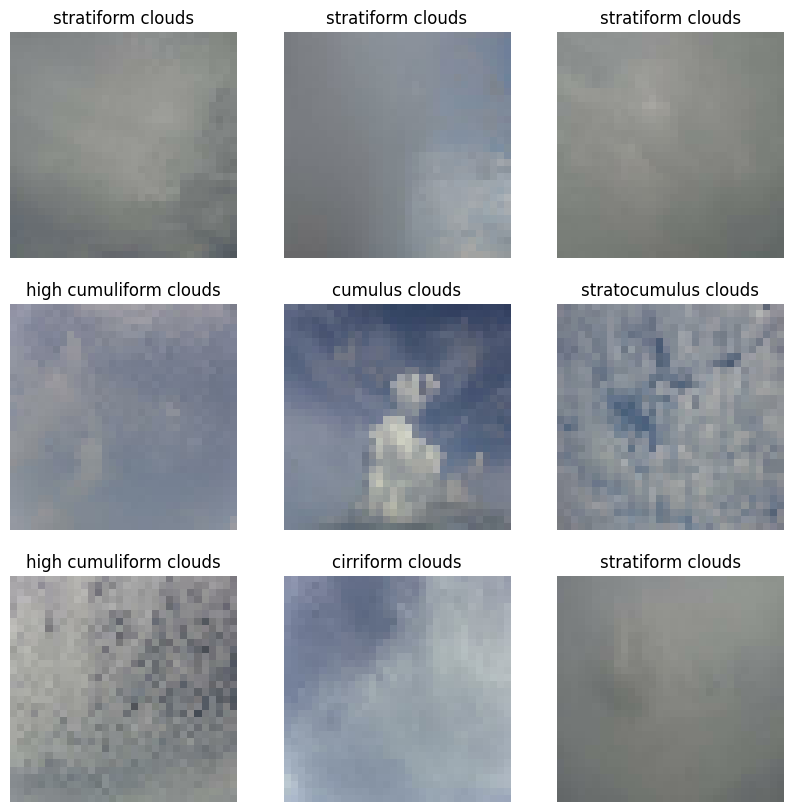

In [17]:
# ✅ Access class names from the *original dataset before skip/take*
class_names = test_ds.class_names
print("Class names:", class_names)

# Display sample images
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):  # take one batch
    for i in range(9):  # show 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()
